In [101]:
"""
User_ID: معرف فريد (1-25000).
Name: اسم المستخدم (متكرر، قد يكون مولدًا).
Age: عمر (13-80 سنة).
Country: بلد الإقامة (حوالي 20 دولة، تكثر USA وCanada).
Subscription_Type: نوع اشتراك ("Basic"، "Standard"، "Premium").
Watch_Time_Hours: ساعات المشاهدة (0.22-999.73).
Favorite_Genre: النوع المفضل (مثل Drama، Sci-Fi، 9 أنواع).
Last_Login: آخر تسجيل دخول (مارس 2024-مارس 2025).
"""

'\nUser_ID: معرف فريد (1-25000).\nName: اسم المستخدم (متكرر، قد يكون مولدًا).\nAge: عمر (13-80 سنة).\nCountry: بلد الإقامة (حوالي 20 دولة، تكثر USA وCanada).\nSubscription_Type: نوع اشتراك ("Basic"، "Standard"، "Premium").\nWatch_Time_Hours: ساعات المشاهدة (0.22-999.73).\nFavorite_Genre: النوع المفضل (مثل Drama، Sci-Fi، 9 أنواع).\nLast_Login: آخر تسجيل دخول (مارس 2024-مارس 2025).\n'

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nbformat as nbf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer,FunctionTransformer



In [103]:

try:
    Data = pd.read_csv('netflix_users.csv')
except ImportError as e:
    print(f"Error importing data: {e}")

In [104]:
Data.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [105]:
Data.shape

(25000, 8)

In [106]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


In [107]:
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,25000.0,12500.500000,7217.022701,1.00,6250.7500,12500.500,18750.2500,25000.00
Age,25000.0,46.482880,19.594861,13.00,29.0000,46.000,63.0000,80.00
Watch_Time_Hours,25000.0,500.468858,286.381815,0.12,256.5675,501.505,745.7325,999.99


In [108]:
Data.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

In [109]:
Data.duplicated().sum()

np.int64(0)

In [110]:
Data.drop(columns=['User_ID'] , inplace=True)

In [111]:
Data['Last_Login'] = pd.to_datetime(Data['Last_Login'], format='%Y-%m-%d')

In [112]:
print("The information of the DataFrame after convert 'Last_Login' to DateTime:")
print("-" * 50)
Data.info()

The information of the DataFrame after convert 'Last_Login' to DateTime:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               25000 non-null  object        
 1   Age                25000 non-null  int64         
 2   Country            25000 non-null  object        
 3   Subscription_Type  25000 non-null  object        
 4   Watch_Time_Hours   25000 non-null  float64       
 5   Favorite_Genre     25000 non-null  object        
 6   Last_Login         25000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 1.3+ MB


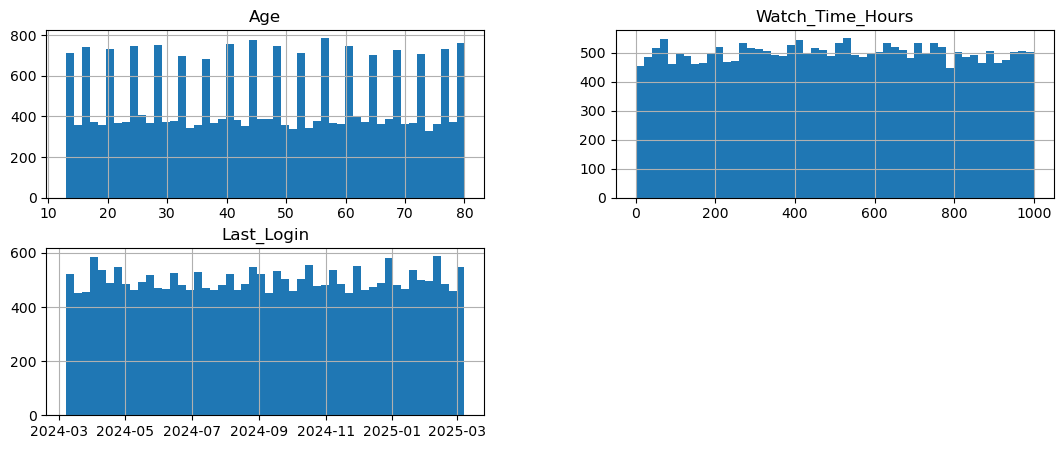

In [113]:
Data.hist(bins=50,figsize=(13,5))
plt.show()

In [114]:
Data['Age'].value_counts()

Age
26    407
40    406
45    405
57    404
62    400
     ... 
13    339
51    338
73    334
74    330
36    326
Name: count, Length: 68, dtype: int64

In [115]:
fig = px.histogram(Data , x = 'Age' , nbins=20 , title=' Distribution of User Age')
fig.show()

In [116]:
fig = px.box(Data , x = 'Age' , title=' Box Plot of User Age')
fig.show()

In [117]:
Data['Country'].value_counts()

Country
UK           2592
Germany      2547
India        2505
USA          2503
Brazil       2503
Mexico       2493
Canada       2490
France       2473
Japan        2457
Australia    2437
Name: count, dtype: int64

In [118]:
Country_Count = Data['Country'].value_counts()
fg1 = px.bar(
    Country_Count,
    x=Country_Count.index,
    y=Country_Count.values,
    title='Countries Count',
    labels={'x': 'Country', 'y': 'Count'},
    color=Country_Count.values,
    color_continuous_scale='Viridis'

)
fg1.show()

In [119]:
country_count_df = Country_Count.reset_index()
fg1 = px.pie(
    country_count_df,
    values='count',
    names='Country',
    title='Percentage of Users by Country'
)
fg1.show()

In [120]:
Data['Subscription_Type'].unique()

array(['Premium', 'Basic', 'Standard'], dtype=object)

In [121]:
Subscription_Type_count = Data['Subscription_Type'].value_counts() 
Subscription_Type_count

Subscription_Type
Premium     8402
Basic       8356
Standard    8242
Name: count, dtype: int64

In [122]:
Subscription_Type_count_df = Subscription_Type_count.reset_index()
fig = px.pie(Subscription_Type_count_df, 
            names='Subscription_Type',
            values='count',
            title='Subscription Type Distribution',
            color='Subscription_Type',

            )
fig.show()

In [123]:
country_sub_counts =  Data.groupby(['Country'])['Subscription_Type'].value_counts() 
country_sub_counts

Country    Subscription_Type
Australia  Premium              836
           Standard             815
           Basic                786
Brazil     Premium              858
           Basic                823
           Standard             822
Canada     Standard             865
           Premium              830
           Basic                795
France     Basic                872
           Premium              819
           Standard             782
Germany    Premium              877
           Standard             845
           Basic                825
India      Basic                849
           Standard             834
           Premium              822
Japan      Premium              828
           Standard             817
           Basic                812
Mexico     Basic                864
           Premium              832
           Standard             797
UK         Basic                873
           Standard             870
           Premium              849

In [124]:
country_sub_counts_df = country_sub_counts.reset_index()
fig = px.bar(country_sub_counts_df,
              x='Country',
              y='count',
              color='Subscription_Type',
              title='Subscription Type Count by Country',
              labels={'Country': 'Country', 'count': 'Count', 'Subscription_Type': 'Subscription Type'},
                  color_discrete_map={
                'standard': 'lightblue',
                'Basic': 'lightgreen',
                'Premium': 'skyblue',
                }
            )
fig.show()

In [125]:
# حساب متوسط الأعمار حسب البلد ونوع الاشتراك
country_age_mean = Data.groupby(['Country', 'Subscription_Type'])['Age'].mean().reset_index()
fig= px.bar(
    country_age_mean,
    x='Country',
    y='Age',
    color='Subscription_Type',
    title='Average Age by Country and Subscription Type',
    labels={'Country': 'Country', 'Age': 'Average Age', 'Subscription_Type': 'Subscription Type'},
    color_discrete_map={
        'standard': 'lightblue',
        'Basic': 'lightgreen',
        'Premium': 'skyblue',
    }
)
fig.show()

In [126]:
fig = px.histogram(Data , x = 'Watch_Time_Hours' , nbins=20 , title=' Distribution of Watch Time Hours')
fig.show()

In [127]:
fig = px.box(Data, y='Watch_Time_Hours', title='Box Plot of Watch Time Hours')
fig.show()

In [128]:
fig = px.bar(Data.groupby('Subscription_Type')['Watch_Time_Hours'].mean().reset_index(), 
             x='Subscription_Type', 
             y='Watch_Time_Hours', 
             title='Average Watch Time by Subscription Type')
fig.show()

In [129]:
Data['Favorite_Genre'].value_counts()

Favorite_Genre
Horror         3654
Documentary    3636
Action         3589
Romance        3572
Comedy         3561
Drama          3533
Sci-Fi         3455
Name: count, dtype: int64

In [130]:
Favortite_count = Data['Favorite_Genre'].value_counts()
fig = px.bar(
    Favortite_count,
    x=Favortite_count.index,
    y=Favortite_count.values,
    title='Favorite Genre Count',
    labels={'x': 'Favorite Genre', 'y': 'Count'},
    color=Favortite_count.values,
    color_continuous_scale='Viridis'
)
fig.show()

In [131]:
fig = px.pie(
    Favortite_count.reset_index(),
    values='count',
    names='Favorite_Genre',
    title='Percentage of Users by Favorite Genre',
    color='Favorite_Genre',
)
fig.show()

In [132]:
favorite_Genre = Data.groupby('Favorite_Genre')['Country'].value_counts()
favorite_Genre

Favorite_Genre  Country
Action          Canada     378
                India      372
                Germany    370
                France     367
                Brazil     364
                          ... 
Sci-Fi          Japan      340
                Brazil     337
                France     322
                Canada     321
                USA        319
Name: count, Length: 70, dtype: int64

In [133]:
Favorite_Genre_df = favorite_Genre.reset_index(name='count')
fig = px.bar(
    Favorite_Genre_df,
    x='Favorite_Genre',
    y='count',
    color='Country',
    title='Favorite Genre Count by Country',
    labels={'Favorite_Genre': 'Favorite Genre', 'count': 'Count', 'Country': 'Country'},

)
fig.show()

In [134]:
fig = px.line(Data.groupby(pd.to_datetime(Data['Last_Login']).dt.date).size().reset_index(name='Count'), 
              x='Last_Login', y='Count', title='User Activity Over Time')
fig.show()

In [135]:
Data['Login_Year'] = Data['Last_Login'].dt.year
Data['Login_Month'] = Data['Last_Login'].dt.month
Data['Login_Day'] = Data['Last_Login'].dt.day
Data = Data.drop(columns=['Last_Login'])  # بعد ما تستخرج منها المعلومات

In [140]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               25000 non-null  object 
 1   Age                25000 non-null  int64  
 2   Country            25000 non-null  object 
 3   Subscription_Type  25000 non-null  object 
 4   Watch_Time_Hours   25000 non-null  float64
 5   Favorite_Genre     25000 non-null  object 
 6   Login_Year         25000 non-null  int32  
 7   Login_Month        25000 non-null  int32  
 8   Login_Day          25000 non-null  int32  
dtypes: float64(1), int32(3), int64(1), object(4)
memory usage: 1.4+ MB


In [136]:
Data.head()

,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Login_Year,Login_Month,Login_Day
0,James Martinez,18,France,Premium,80.26,Drama,2024,5,12
1,John Miller,23,USA,Premium,321.75,Sci-Fi,2025,2,5
2,Emma Davis,60,UK,Basic,35.89,Comedy,2025,1,24
3,Emma Miller,44,USA,Premium,261.56,Documentary,2024,3,25
4,Jane Smith,68,USA,Standard,909.30,Drama,2025,1,14


In [141]:
numerical_cols = Data.select_dtypes(include=['int32','int64', 'float64']).columns.tolist()
categorical_cols = Data.select_dtypes(include=['object']).columns.tolist()
print(f"The numerical columns are: {numerical_cols} and The number of columes are: {len(numerical_cols)}")
print(f"The categorical columns are: {categorical_cols} and The number of columes are: {len(categorical_cols)}")

The numerical columns are: ['Age', 'Watch_Time_Hours', 'Login_Year', 'Login_Month', 'Login_Day'] and The number of columes are: 5
The categorical columns are: ['Name', 'Country', 'Subscription_Type', 'Favorite_Genre'] and The number of columes are: 4


In [142]:
corr_matrix=Data[numerical_cols].corr()
corr_matrix

,Age,Watch_Time_Hours,Login_Year,Login_Month,Login_Day
Age,1.000000,0.007981,0.010869,-0.004257,0.006907
Watch_Time_Hours,0.007981,1.000000,-0.002569,0.012228,-0.003374
Login_Year,0.010869,-0.002569,1.000000,-0.669246,-0.096613
Login_Month,-0.004257,0.012228,-0.669246,1.000000,0.028481
Login_Day,0.006907,-0.003374,-0.096613,0.028481,1.000000


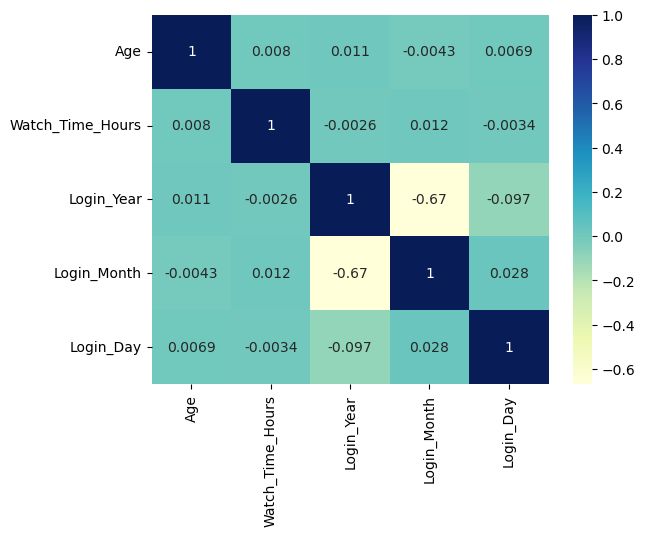

In [143]:
plt.figsize=(10, 10)
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.show()


In [144]:
train, test = train_test_split(Data, test_size=0.2, random_state=13)
print("Train shape: ", train.shape)
print("Test shape: ", test.shape)

Train shape:  (20000, 9)
Test shape:  (5000, 9)


In [145]:
def clip_outliers_df(Data):
    Data = pd.DataFrame(Data).copy()
    for col in Data.columns:
        Q1 = Data[col].quantile(0.25)
        Q3 = Data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        MED = Data[col].median()
        Data.loc[(Data[col] < lower_bound) | Data[col] > upper_bound, col] = MED
        
    return Data.values

In [150]:
outlier_handler = FunctionTransformer(clip_outliers_df) # علشان نقدر نستخدمها كخطوة جوه Pipeline

In [151]:
num_pipeline = Pipeline([
    ('Imputer' , SimpleImputer(strategy='median')), #Missing Values
    ('Handel_outliers' ,outlier_handler )
])

In [152]:
cat_pipeline = Pipeline([
    ('Imputer' , SimpleImputer(strategy='most_frequent')),
    ('Encoding' , OneHotEncoder())
])

In [153]:
Proccess = ColumnTransformer([
    ('NUM', Pipeline(num_pipeline), numerical_cols),
    ('CAT', cat_pipeline, categorical_cols)
])

In [154]:
train.head()

,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Login_Year,Login_Month,Login_Day
4455,Alex Johnson,52,Japan,Premium,251.93,Action,2024,8,10
7527,Alex Garcia,45,Mexico,Standard,850.16,Action,2024,7,18
8439,Michael Jones,55,Japan,Premium,757.15,Documentary,2025,1,25
15558,Chris Hernandez,17,France,Basic,96.56,Comedy,2024,9,13
14705,Alex Davis,21,India,Premium,353.86,Romance,2024,4,11


In [155]:
test.head()

,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Login_Year,Login_Month,Login_Day
24233,Michael Garcia,66,Mexico,Premium,782.89,Romance,2024,6,21
11467,Sarah Miller,61,UK,Standard,783.06,Horror,2025,1,2
12033,Chris Davis,44,Canada,Premium,445.57,Sci-Fi,2024,8,10
3079,James Johnson,64,France,Standard,878.70,Action,2024,4,8
6472,Michael Smith,36,UK,Standard,636.44,Sci-Fi,2024,8,5


In [156]:
S_scaler = StandardScaler()
train[numerical_cols] = S_scaler.fit_transform(train[numerical_cols])
test[numerical_cols] = S_scaler.transform(test[numerical_cols])
train.head()



,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Login_Year,Login_Month,Login_Day
4455,Alex Johnson,0.283199,Japan,Premium,-0.871229,Action,-0.479833,0.429944,-0.640135
7527,Alex Garcia,-0.073651,Mexico,Standard,1.220125,Action,-0.479833,0.141304,0.267866
8439,Michael Jones,0.436135,Japan,Premium,0.894971,Documentary,2.084060,-1.590538,1.062366
15558,Chris Hernandez,-1.501052,France,Basic,-1.414387,Comedy,-0.479833,0.718585,-0.299634
14705,Alex Davis,-1.297138,India,Premium,-0.514891,Romance,-0.479833,-0.724617,-0.526635


In [ ]:
train[numerical_cols].describe().T 

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,4.813927e-17,1.000025,-1.704966,-0.889309,-0.022673,0.843963,1.710599
Watch_Time_Hours,20000.0,2.970069e-16,1.000025,-1.751532,-0.851713,0.004040,0.857215,1.743916
Login_Year,20000.0,6.621708e-14,1.000025,-0.479833,-0.479833,-0.479833,-0.479833,2.084060
Login_Month,20000.0,8.526513e-17,1.000025,-1.590538,-0.724617,0.141304,1.007225,1.584506
Login_Day,20000.0,-8.988366e-17,1.000025,-1.661635,-0.867135,0.040866,0.835366,1.743367
